# Install libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

from pathlib import Path

# Opening cleaned PAROS dataset

In [3]:
CURRENT_DIRECTORY = Path.cwd().resolve()

# Find project root that contains datasets
PROJECT_ROOT = next(
    p for p in [CURRENT_DIRECTORY, *CURRENT_DIRECTORY.parents]
    if (p / "datasets").exists()
)

CLEANED_DATASET_PATH = PROJECT_ROOT / "datasets" / "PAROS_Dataset_Cleaned.csv"

if not CLEANED_DATASET_PATH.exists():
    raise FileNotFoundError(f"Cleaned dataset not found: {CLEANED_DATASET_PATH}")

df = pd.read_csv(CLEANED_DATASET_PATH)
print(f"Loaded cleaned PAROS dataset: {df.shape}")
display(df.head(3))

Loaded cleaned PAROS dataset: (28665, 67)


/tmp/ipykernel_32847/1582093032.py:14: DtypeWarning: Columns (5,32,33,37,43,46,47,48,49,50,51,52,53,60) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CLEANED_DATASET_PATH)


,Patient brought in by,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,Age,Age Modifier,Gender,Race,...,ANY ROSC,Cause of arrest.1,"If 'Non-Trauma', please specify.1",Reason for discontinuing CPR at ED,Outcome of patient,Patient status,Date of Discharge or Death,Patient neurological status - Cerebral,Patient neurological status - Overall,Patient neurological status - Unknown
0,Ems,2010-04-01,470146.0,NaN,Home Residence,Hdb Level 7,60,Years,Male,Chinese,...,Yes,Non-Trauma,Respiratory,Death,Died In Ed,NaN,NaN,NaN,NaN,NaN
1,Ems,2010-04-01,520926.0,NaN,Home Residence,Hdb Level 2,60,Years,Female,Chinese,...,No,Non-Trauma,Presumed Cardiac Etiology,Death,Died In Ed,NaN,NaN,NaN,NaN,NaN
2,Ems,2010-04-01,560565.0,NaN,Healthcare Facility,Nkf Dialysis Centre,64,Years,Male,Chinese,...,Yes,Non-Trauma,Presumed Cardiac Etiology,Death,Died In Ed,NaN,NaN,NaN,NaN,NaN


In [4]:
print(df.columns.tolist())


['Patient brought in by', 'Date of Incident', 'Location of incident', 'Location Unknown', 'Location Type', 'Location Type Other', 'Age', 'Age Modifier', 'Gender', 'Race', 'Time call received at dispatch center', 'No First Responder dispatched', 'Time First Responder dispatched', 'Time Ambulance dispatched', 'Time First Responder arrived at scene', 'Time Ambulance arrived at scene', 'Time EMS arrived at patient side', 'Time Ambulance arrived at ED', 'Arrest witnessed by', 'Bystander CPR', 'DA-CPR', 'First CPR initiated by', 'Bystander AED applied', 'Resuscitation attempted by EMS/Private ambulance', 'First arrest rhythm', 'Prehospital Defibrillation', 'Time of first shock given', 'Time of first shock Unknown', 'Defibrillation performed by - First Responder', 'Defibrillation performed by - Ambulance Crew', 'Defibrillation performed by - Bystander - Healthcare provider', 'Defibrillation performed by - Bystander - Lay Person', 'Defibrillation performed by - Bystander - Family', 'Other', 'R

In [5]:
df['Cause of arrest'].value_counts(dropna=False)

Cause of arrest
NaN           27480
Non-Trauma     1185
Name: count, dtype: int64

# Setting columns for feature engineering

In [6]:
# This will be used to calculate time to defib
call_time_col = 'Time call received at dispatch center'
shock_time_col = 'Time of first shock given'
ems_cpr_time_col = 'Time CPR started by EMS/Private ambulance'

# This will be used to calculate into a binary status of 0/1 survival
status_col = 'Patient status'

df_survival = df.copy()
# display(df_survival[[call_time_col, shock_time_col, status_col]].head())

# Calculating the time to defib

In [7]:
df_survival["Call_Time"] = pd.to_datetime(df_survival[call_time_col].astype(str),
                                          format = "mixed",
                                          errors='coerce')
df_survival['Shock_Time'] = pd.to_datetime(df_survival[shock_time_col].astype(str),
                                           format='mixed',
                                           errors='coerce')

# Calculate the difference in minutes
df_survival['Time_to_Defib'] = (df_survival['Shock_Time'] - df_survival['Call_Time']).dt.total_seconds() / 60

# Calculate time to EMS CPR as well
df_survival['EMS_CPR_Time'] = pd.to_datetime(
    df_survival[ems_cpr_time_col].astype(str),
    format='mixed',
    errors='coerce'
)

df_survival['Time_from_Call_to_EMS_CPR'] = (
    df_survival['EMS_CPR_Time'] - df_survival['Call_Time']
).dt.total_seconds() / 60


# Fix midnight crossover overlaps
df_survival.loc[df_survival['Time_to_Defib'] < 0, 'Time_to_Defib'] += 1440
df_survival.loc[df_survival['Time_from_Call_to_EMS_CPR'] < 0, 'Time_from_Call_to_EMS_CPR'] += 1440


# display(df_survival[['Call_Time', 'Shock_Time', 'Time_to_Defib']].head(10))

/tmp/ipykernel_32847/1344508742.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_survival["Call_Time"] = pd.to_datetime(df_survival[call_time_col].astype(str),
/tmp/ipykernel_32847/1344508742.py:4: FutureWarning: ChainedAssignmentError

KeyError: 'Time CPR started by EMS/Private ambulance'

Time to defib will show 13.9 minutes (standard decimal format)

Example (Index 0):
-   54 seconds ÷ 60 seconds = 0.90 minutes.
-   13 minutes + 0.90 minutes = 13.90 minutes.

# Feature Engineering for Survival Status

- 0 = Dead
- 1 = Survived

In [ ]:
df_survival['Survival_Status'] = df_survival[status_col].astype(str).str.contains('Discharged|Alive|Remains', 
                                                                                  case=False, 
                                                                                  na=False
).astype(int)
df_survival['Survival_Status'] = df_survival['Survival_Status'].astype(int)

# display(df_survival[['Time_to_Defib', 'Survival_Status']].head())

/tmp/ipykernel_28485/942202956.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_survival['Survival_Status'] = df_survival[status_col].astype(str).str.contains('Discharged|Alive|Remains',
/tmp/ipykernel_28485/942202956.py:5: FutureWarni

# Filter to a standard range (e.g., 0-20 minutes)
- This is to avoid extreme outliers skewing the fit

In [ ]:
df_plot = df_survival[(df_survival['Time_to_Defib'] >= 0) & (df_survival['Time_to_Defib'] <= 20)].copy()


# Define the Piecewise Linear Regression Model (Change-point Model)
- It features an initial slope (b1) that switches to a second slope (b2) at time 'tau'

In [ ]:
def piecewise_linear(x, tau, b0, b1, b2):
    return np.where(x < tau, 
                    b0 + b1 * x, 
                    b0 + b1 * tau + b2 * (x - tau))

# Standardize data to the 0-20 min window
df_analysis = df_survival[(df_survival['Time_to_Defib'] >= 0) & (df_survival['Time_to_Defib'] <= 20)].copy()

# Setup arrays to store results
bin_labels = ['Continuous\n(Raw Data)']
estimated_taus = []

# Fit the Continuous (Unbinned) Baseline

In [ ]:
x_cont = df_analysis['Time_to_Defib'].values
y_cont = df_analysis['Survival_Status'].values

# Initial guesses: Tau=6 min, int=0.5, slope1=-0.05, slope2=0
try:
    popt_cont, _ = curve_fit(piecewise_linear, x_cont, y_cont, 
                             p0=[6.0, 0.5, -0.05, 0.0], 
                             bounds=([1, 0, -1, -1], [18, 1, 1, 1]))
    estimated_taus.append(popt_cont[0])
except Exception as e:
    print(f"Continuous fit failed: {e}")
    estimated_taus.append(np.nan)

# Fit the Binned Models (2-min, 3-min, 5-min)

In [ ]:
bin_sizes = [2, 3, 5]

for b in bin_sizes:
    bin_labels.append(f'{b}-min Bins')
    
    # Bin the time based on size 'b'
    df_analysis[f'Bin_{b}'] = np.floor(df_analysis['Time_to_Defib'] / b) * b
    
    # Calculate survival probability per bin
    binned = df_analysis.groupby(f'Bin_{b}').agg(
        Survival_Probability=('Survival_Status', 'mean')
    ).reset_index()
    
    # Use the midpoint of the bin for an accurate spatial representation
    x_binned = binned[f'Bin_{b}'] + (b / 2.0)
    y_binned = binned['Survival_Probability']
    
    try:
        popt_binned, _ = curve_fit(piecewise_linear, x_binned, y_binned, 
                                   p0=[6.0, 0.5, -0.05, 0.0], 
                                   bounds=([1, 0, -1, -1], [18, 1, 1, 1]))
        estimated_taus.append(popt_binned[0])
    except Exception as e:
        print(f"Fit failed for {b}-min bin: {e}")
        estimated_taus.append(np.nan)

/tmp/ipykernel_28485/2642486879.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_analysis[f'Bin_{b}'] = np.floor(df_analysis['Time_to_Defib'] / b) * b
/tmp/ipykernel_28485/2642486879.py:7: FutureWarning: ChainedAssignmentError: behavio

# Plot out the Deviation Chart

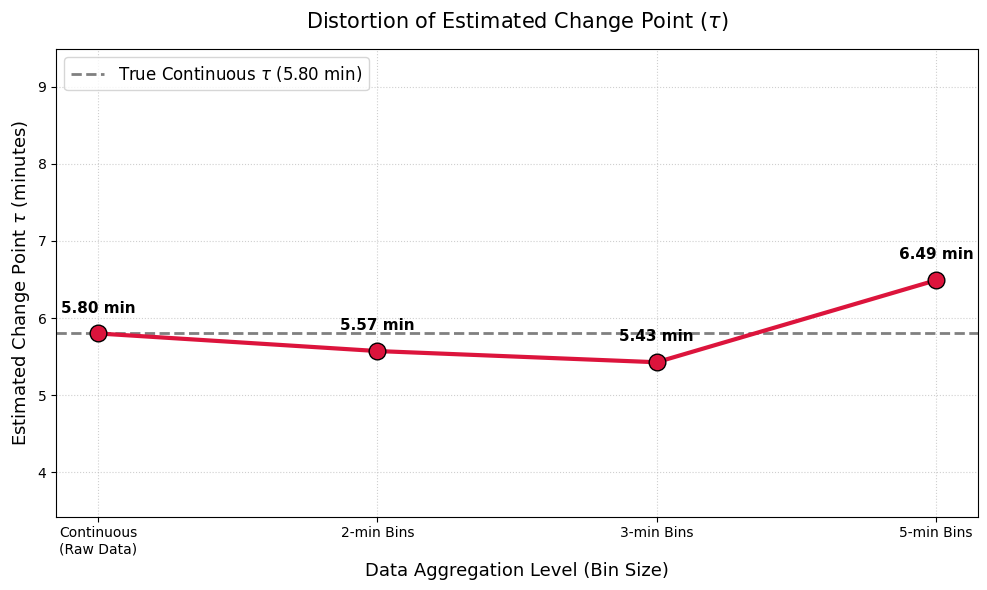

In [ ]:
plt.figure(figsize=(10, 6))

# The Main Line Plot showing the drift
plt.plot(bin_labels,
         estimated_taus,
         marker='o',
         markersize=12,
         color='crimson', 
         linewidth=3,
         markeredgecolor='black',
         zorder=3)

# Add a horizontal dashed line representing the 'True Continuous' baseline
baseline_tau = estimated_taus[0]
plt.axhline(y=baseline_tau,
            color='gray',
            linestyle='--',
            linewidth=2, 
            label=f'True Continuous $\\tau$ ({baseline_tau:.2f} min)', zorder=1)

# Annotate each point with its specific Tau value
for i, tau_val in enumerate(estimated_taus):
    if not np.isnan(tau_val):
        plt.annotate(f"{tau_val:.2f} min", 
                     (i, tau_val), 
                     textcoords="offset points", 
                     xytext=(0,15), 
                     ha='center', 
                     fontsize=11, 
                     fontweight='bold')

# Labelling
plt.title('Distortion of Estimated Change Point ($\\tau$)', fontsize=15, pad=15)
plt.xlabel('Data Aggregation Level (Bin Size)', fontsize=13)
plt.ylabel('Estimated Change Point $\\tau$ (minutes)', fontsize=13)

# Dynamically set Y-axis limits so annotations aren't cut off
valid_taus = [t for t in estimated_taus if not np.isnan(t)]
if valid_taus:
    plt.ylim(max(0, min(valid_taus) - 2), max(valid_taus) + 3)

plt.grid(axis='both', linestyle=':', alpha=0.6)
plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()

plt.show()